In [1]:
# Auto-reload modules when they change
%load_ext autoreload
%autoreload 2

# make matplotlib render svg
%config InlineBackend.figure_format = 'svg'

import torch
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.utils import load_full_config
from src.mgf_dataset import create_mgf_dataset
from src.mgf_dataset import simulate_ou_process
from src.model import SimpleTransformer
from src.model import HermiteEmbedding

# Compute likelihood of test theta values based on training distribution
from scipy.stats import lognorm

In [40]:
# Generate test dataset with fixed marginal variance and varying theta
import numpy as np

# Test dataset parameters
num_theta_values = 100  # Number of different theta values to test
sequence_length = 5
mu = 0.0
dt = 0.1
fixed_marginal_variance = np.sqrt(0.2)  # Fixed across all trajectories


theta_tensor = torch.tensor([3.]).float()
D_tensor = torch.tensor([0.1]).float()

# Generate trajectories
input = simulate_ou_process(1, 100, theta_tensor, mu, D_tensor, dt)

In [41]:
hermite = HermiteEmbedding(L=10, normalize=True)
E = hermite(input)                 # shape (1, T, L+1)

# Extract first two components
H0 = E[0, :, 1].detach().cpu().numpy()
H1 = E[0, :, 2].detach().cpu().numpy()
H2 = E[0, :, 5].detach().cpu().numpy()

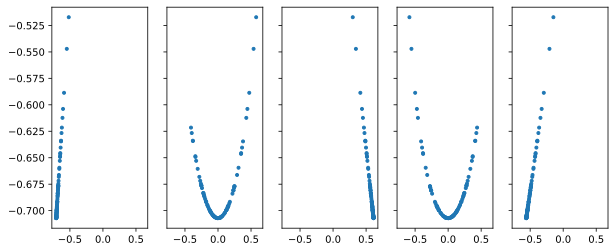

In [44]:
fig,axs= plt.subplots(figsize=(10,4),ncols=5,sharex=True,sharey=True)

for i in range(5):
    ax = axs[i]
    H1 = E[0, :, 2].detach().cpu().numpy()
    Hi = E[0, :, i+2].detach().cpu().numpy()
    ax.plot(Hi, H1,".")